## Análisis y Tratamiento Digital de Imágenes Satelitales: TP3

In [ ]:
pip install rasterio matplotlib
pip install opencv-python

In [1]:
from __future__ import annotations
import os
import numpy as np
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import requests
import io
from PIL import Image
from io import BytesIO
from IPython.display import display
import cv2

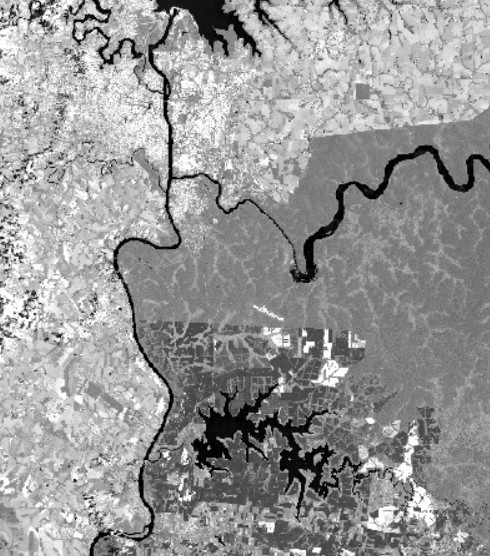

In [2]:
url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales3/refs/heads/main/LC08_224-078-2018-01-05_swir1.jpeg"

response = requests.get(url)

img = Image.open(BytesIO(response.content))

display(img)

### 1. Implementar los siguientes algoritmos de umbralización y aplicarlos a una imagen de grises o color, según corresponda.

##### a) Umbralización iterativa.

Umbral encontrado: 152.78305058259983


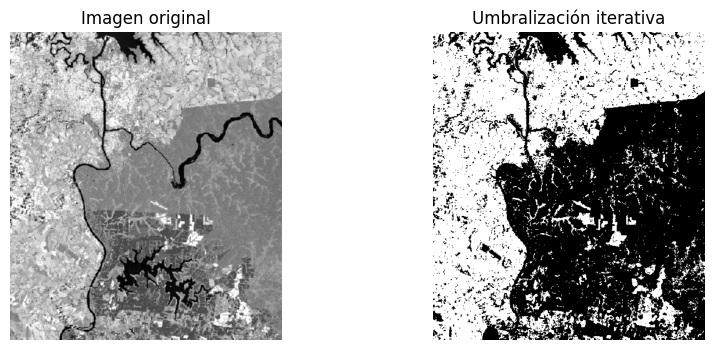

In [3]:
# Convertir la imagen a escala de grises
gray = np.array(img.convert("L"))

# Umbralización iterativa
def umbralizacion_iterativa(imagen, tolerancia=0.5):

    # Umbral inicial: promedio de los píxeles
    T = np.mean(imagen)

    while True:
        # Grupo de píxeles menores o iguales al umbral
        grupo1 = imagen[imagen <= T]

        # Grupo de píxeles mayores al umbral
        grupo2 = imagen[imagen > T]

        # Evitar problemas si algún grupo está vacío
        if len(grupo1) == 0 or len(grupo2) == 0:
            break

        # Promedio de cada grupo
        m1 = np.mean(grupo1)
        m2 = np.mean(grupo2)

        # Nuevo umbral
        nuevo_T = (m1 + m2) / 2

        # Comprobar si el umbral ya no cambia significativamente
        if abs(nuevo_T - T) < tolerancia:
            T = nuevo_T
            break

        T = nuevo_T

    # Crear imagen binaria
    imagen_binaria = np.where(imagen > T, 255, 0).astype(np.uint8)

    return imagen_binaria, T


# Aplicar el algoritmo
imagen_binaria, umbral = umbralizacion_iterativa(gray)

# Mostrar resultados
print("Umbral encontrado:", umbral)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_binaria, cmap="gray")
plt.title("Umbralización iterativa")
plt.axis("off")

plt.show()

##### b) Método de umbralización de Otsu.

Umbral de Otsu: 153


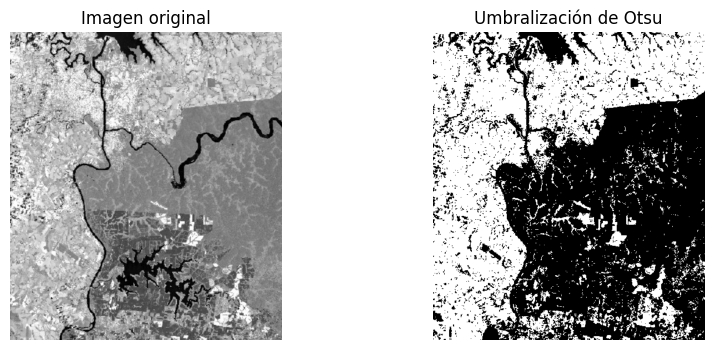

In [4]:
# Calcular el histograma
histograma, valores = np.histogram(gray.flatten(), bins=256, range=(0, 256))

# Número total de píxeles
total = gray.size

# Suma total de intensidades
suma_total = np.sum(np.arange(256) * histograma)

suma_fondo = 0
peso_fondo = 0

varianza_maxima = 0
umbral_otsu = 0

# Buscar el mejor umbral
for t in range(256):

    peso_fondo += histograma[t]

    if peso_fondo == 0:
        continue

    peso_objeto = total - peso_fondo

    if peso_objeto == 0:
        break

    suma_fondo += t * histograma[t]

    media_fondo = suma_fondo / peso_fondo
    media_objeto = (suma_total - suma_fondo) / peso_objeto

    # Varianza entre clases
    varianza = (
        peso_fondo * peso_objeto *
        (media_fondo - media_objeto) ** 2
    )

    if varianza > varianza_maxima:
        varianza_maxima = varianza
        umbral_otsu = t

# Crear imagen binaria
imagen_otsu = np.where(gray > umbral_otsu, 255, 0).astype(np.uint8)

# Mostrar resultado
print("Umbral de Otsu:", umbral_otsu)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_otsu, cmap="gray")
plt.title("Umbralización de Otsu")
plt.axis("off")

plt.show()

##### c) Clasificar una imagen RGB en 8 (o menos) colores, utilizando el método de umbralización banda por banda.


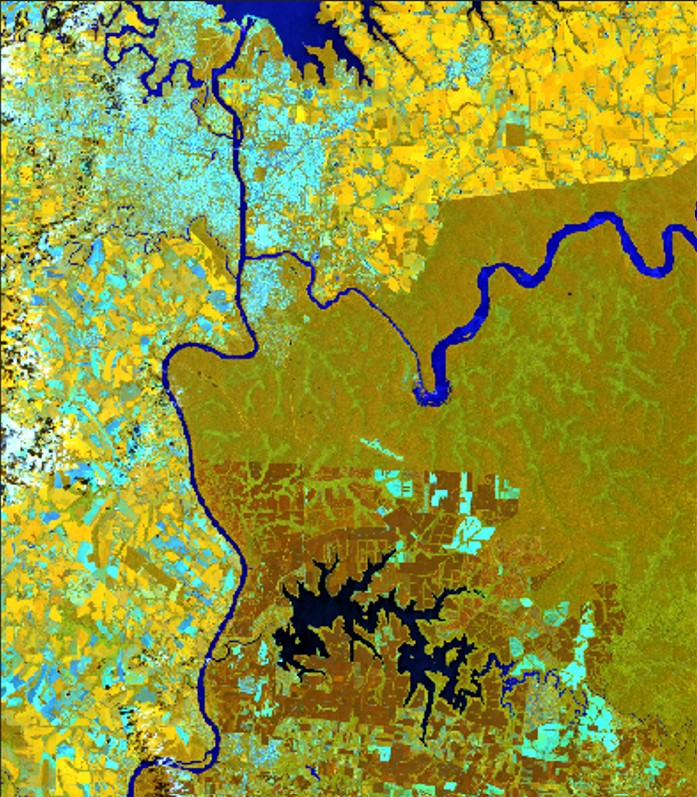

Umbral banda R: 146.49798833142216
Umbral banda G: 151.30165307852798
Umbral banda B: 55.52887351960094


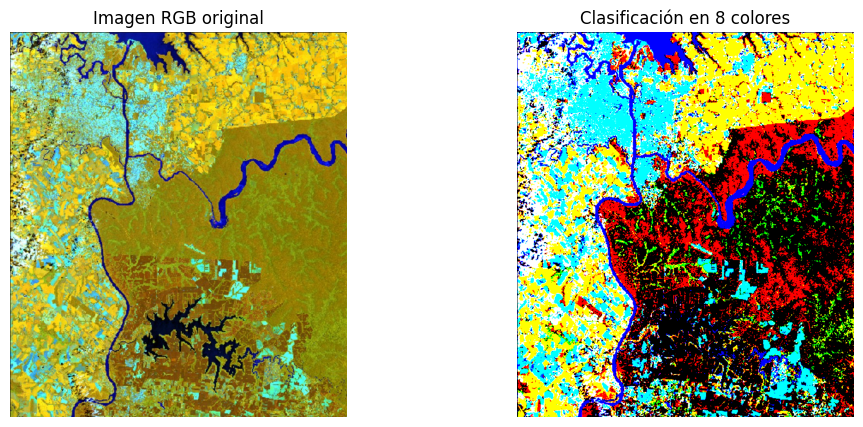

In [7]:
# ============================================================
# 1. Descargar la imagen RGB
# ============================================================

url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales3/refs/heads/main/LC08_224-078-2018-01-05_RGB.jpeg"

response = requests.get(url)

img_rgb = Image.open(BytesIO(response.content)).convert("RGB")

display(img_rgb)


# ============================================================
# 2. Convertir la imagen a una matriz
# ============================================================

rgb = np.array(img_rgb)


# ============================================================
# 3. Separar las bandas R, G y B
# ============================================================

R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]


# ============================================================
# 4. Calcular el umbral de cada banda
# ============================================================

umbral_R = np.mean(R)
umbral_G = np.mean(G)
umbral_B = np.mean(B)

print("Umbral banda R:", umbral_R)
print("Umbral banda G:", umbral_G)
print("Umbral banda B:", umbral_B)


# ============================================================
# 5. Umbralización de cada banda
# ============================================================

R_bin = R > umbral_R
G_bin = G > umbral_G
B_bin = B > umbral_B


# ============================================================
# 6. Crear imagen clasificada en 8 colores
# ============================================================

clasificada = np.zeros_like(rgb)

# Combinación 1
clasificada[(~R_bin) & (~G_bin) & (~B_bin)] = [0, 0, 0]

# Combinación 2
clasificada[(~R_bin) & (~G_bin) & (B_bin)] = [0, 0, 255]

# Combinación 3
clasificada[(~R_bin) & (G_bin) & (~B_bin)] = [0, 255, 0]

# Combinación 4
clasificada[(~R_bin) & (G_bin) & (B_bin)] = [0, 255, 255]

# Combinación 5
clasificada[(R_bin) & (~G_bin) & (~B_bin)] = [255, 0, 0]

# Combinación 6
clasificada[(R_bin) & (~G_bin) & (B_bin)] = [255, 0, 255]

# Combinación 7
clasificada[(R_bin) & (G_bin) & (~B_bin)] = [255, 255, 0]

# Combinación 8
clasificada[(R_bin) & (G_bin) & (B_bin)] = [255, 255, 255]


# ============================================================
# 7. Mostrar resultado
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("Imagen RGB original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clasificada)
plt.title("Clasificación en 8 colores")
plt.axis("off")

plt.show()

### 2. Implementar el detector de borde de Canny y aplicarlo a una imagen utilizando diferentes parámetros.


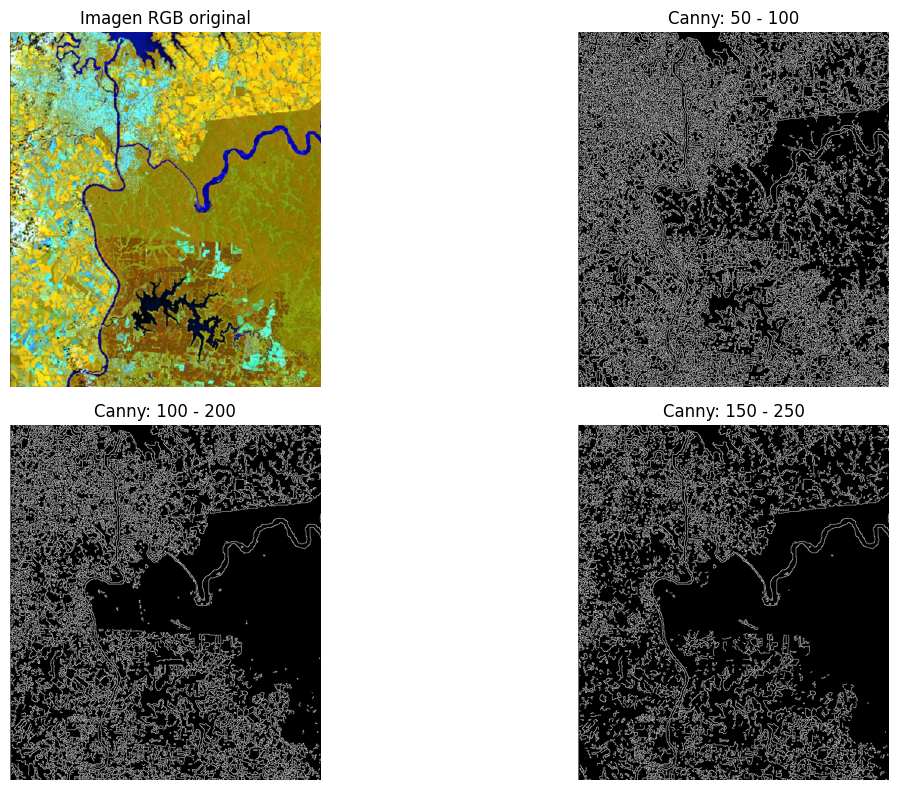

In [8]:


# ============================================================
# 1. Descargar la imagen RGB
# ============================================================

url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales3/refs/heads/main/LC08_224-078-2018-01-05_RGB.jpeg"

response = requests.get(url)

img = Image.open(BytesIO(response.content)).convert("RGB")

# Convertir a NumPy
rgb = np.array(img)

# ============================================================
# 2. Convertir a escala de grises
# ============================================================

gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)


# ============================================================
# 3. Aplicar detector de Canny con diferentes parámetros
# ============================================================

canny_1 = cv2.Canny(gray, 50, 100)

canny_2 = cv2.Canny(gray, 100, 200)

canny_3 = cv2.Canny(gray, 150, 250)


# ============================================================
# 4. Mostrar resultados
# ============================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Imagen RGB original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(canny_1, cmap="gray")
plt.title("Canny: 50 - 100")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(canny_2, cmap="gray")
plt.title("Canny: 100 - 200")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(canny_3, cmap="gray")
plt.title("Canny: 150 - 250")
plt.axis("off")

plt.tight_layout()
plt.show()

### 3. Implementar el Método del Smallest Univaluate Assimilating Nucleus (SUSAN)para:

##### a) Detección de bordes.

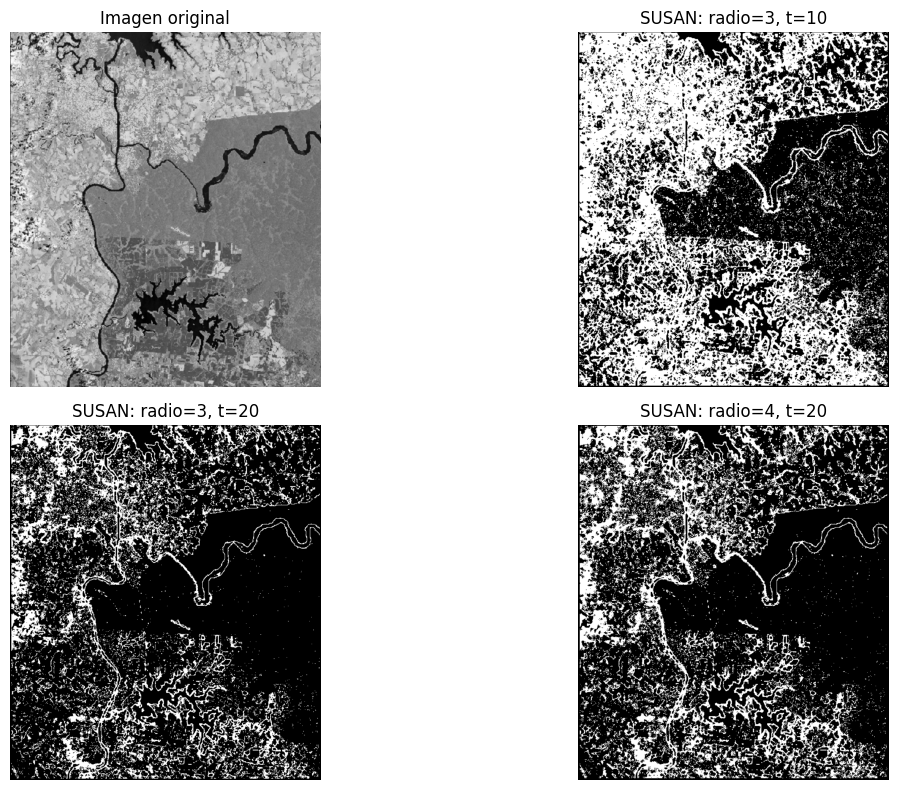

In [10]:
# ============================================================
# 1. Descargar la imagen RGB
# ============================================================

url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales3/refs/heads/main/LC08_224-078-2018-01-05_RGB.jpeg"

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

# Convertir a escala de grises
gray = np.array(img.convert("L"), dtype=np.float32)


# ============================================================
# 2. Implementación de SUSAN para detección de bordes
# ============================================================

def susan_bordes(imagen, radio=3, t=10, umbral=0.5):

    # Crear una copia de la imagen
    resultado = np.zeros_like(imagen)

    # Recorrer la imagen evitando los bordes
    for y in range(radio, imagen.shape[0] - radio):
        for x in range(radio, imagen.shape[1] - radio):

            # Píxel central (núcleo)
            nucleo = imagen[y, x]

            # Contar píxeles similares al núcleo
            similares = 0
            total = 0

            for dy in range(-radio, radio + 1):
                for dx in range(-radio, radio + 1):

                    # Solo considerar píxeles dentro del círculo
                    if dx**2 + dy**2 <= radio**2:

                        total += 1

                        vecino = imagen[y + dy, x + dx]

                        # Comprobar similitud
                        if abs(float(vecino) - float(nucleo)) < t:
                            similares += 1

            # Proporción de píxeles similares
            porcentaje = similares / total

            # En una región uniforme hay muchos píxeles similares.
            # En un borde hay menos píxeles similares.
            if porcentaje < umbral:
                resultado[y, x] = 255

    return resultado


# ============================================================
# 3. Aplicar SUSAN con diferentes parámetros
# ============================================================

susan_1 = susan_bordes(gray, radio=3, t=10, umbral=0.5)

susan_2 = susan_bordes(gray, radio=3, t=20, umbral=0.5)

susan_3 = susan_bordes(gray, radio=4, t=20, umbral=0.5)


# ============================================================
# 4. Mostrar resultados
# ============================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(susan_1, cmap="gray")
plt.title("SUSAN: radio=3, t=10")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(susan_2, cmap="gray")
plt.title("SUSAN: radio=3, t=20")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(susan_3, cmap="gray")
plt.title("SUSAN: radio=4, t=20")
plt.axis("off")

plt.tight_layout()
plt.show()

##### b) Detección de esquinas.

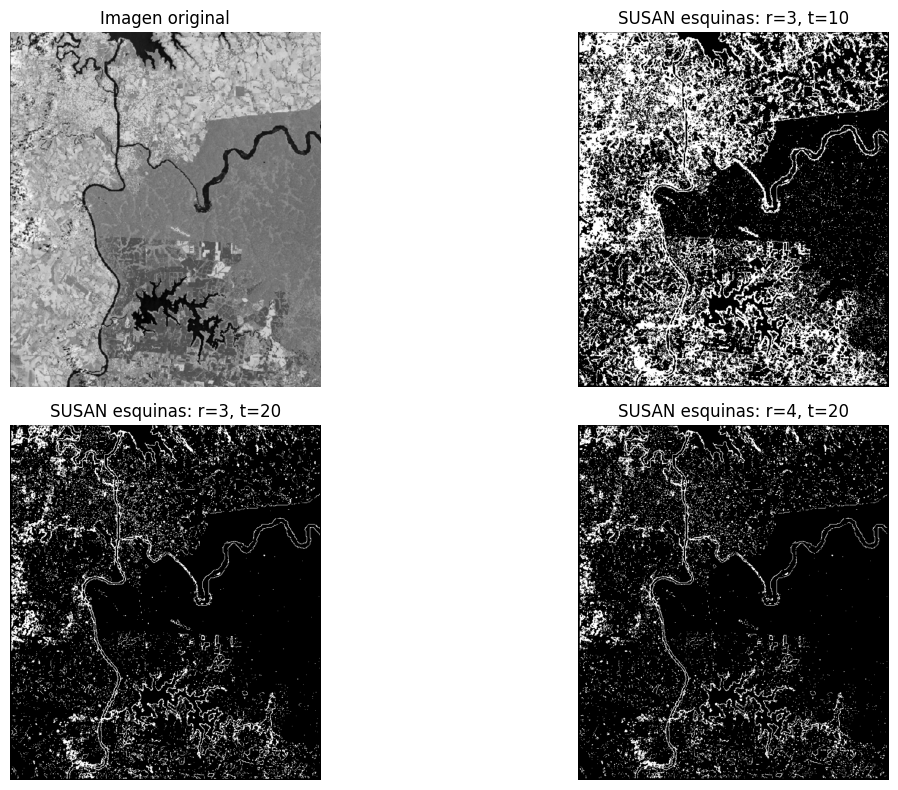

In [11]:
# ============================================================
# 1. Descargar la imagen RGB
# ============================================================

url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales3/refs/heads/main/LC08_224-078-2018-01-05_RGB.jpeg"

response = requests.get(url)

img = Image.open(BytesIO(response.content)).convert("RGB")

# Convertir a escala de grises
gray = np.array(img.convert("L"), dtype=np.float32)


# ============================================================
# 2. SUSAN para detección de esquinas
# ============================================================

def susan_esquinas(imagen, radio=3, t=15, umbral=0.35):

    resultado = np.zeros_like(imagen)

    for y in range(radio, imagen.shape[0] - radio):
        for x in range(radio, imagen.shape[1] - radio):

            # Intensidad del píxel central
            nucleo = imagen[y, x]

            similares = 0
            total = 0

            # Recorrer la vecindad circular
            for dy in range(-radio, radio + 1):
                for dx in range(-radio, radio + 1):

                    # Crear una máscara circular
                    if dx**2 + dy**2 <= radio**2:

                        total += 1

                        vecino = imagen[y + dy, x + dx]

                        # Comparar vecino con el núcleo
                        if abs(float(vecino) - float(nucleo)) < t:
                            similares += 1

            # Proporción de píxeles similares
            porcentaje = similares / total

            # Pocos píxeles similares indican una posible esquina
            if porcentaje < umbral:
                resultado[y, x] = 255

    return resultado


# ============================================================
# 3. Aplicar SUSAN con diferentes parámetros
# ============================================================

esquinas_1 = susan_esquinas(
    gray,
    radio=3,
    t=10,
    umbral=0.35
)

esquinas_2 = susan_esquinas(
    gray,
    radio=3,
    t=20,
    umbral=0.35
)

esquinas_3 = susan_esquinas(
    gray,
    radio=4,
    t=20,
    umbral=0.30
)


# ============================================================
# 4. Mostrar resultados
# ============================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(esquinas_1, cmap="gray")
plt.title("SUSAN esquinas: r=3, t=10")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(esquinas_2, cmap="gray")
plt.title("SUSAN esquinas: r=3, t=20")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(esquinas_3, cmap="gray")
plt.title("SUSAN esquinas: r=4, t=20")
plt.axis("off")

plt.tight_layout()
plt.show()

###### Aplicarlo a una imagen y a sus versiones contaminadas. Analizar los resultados.

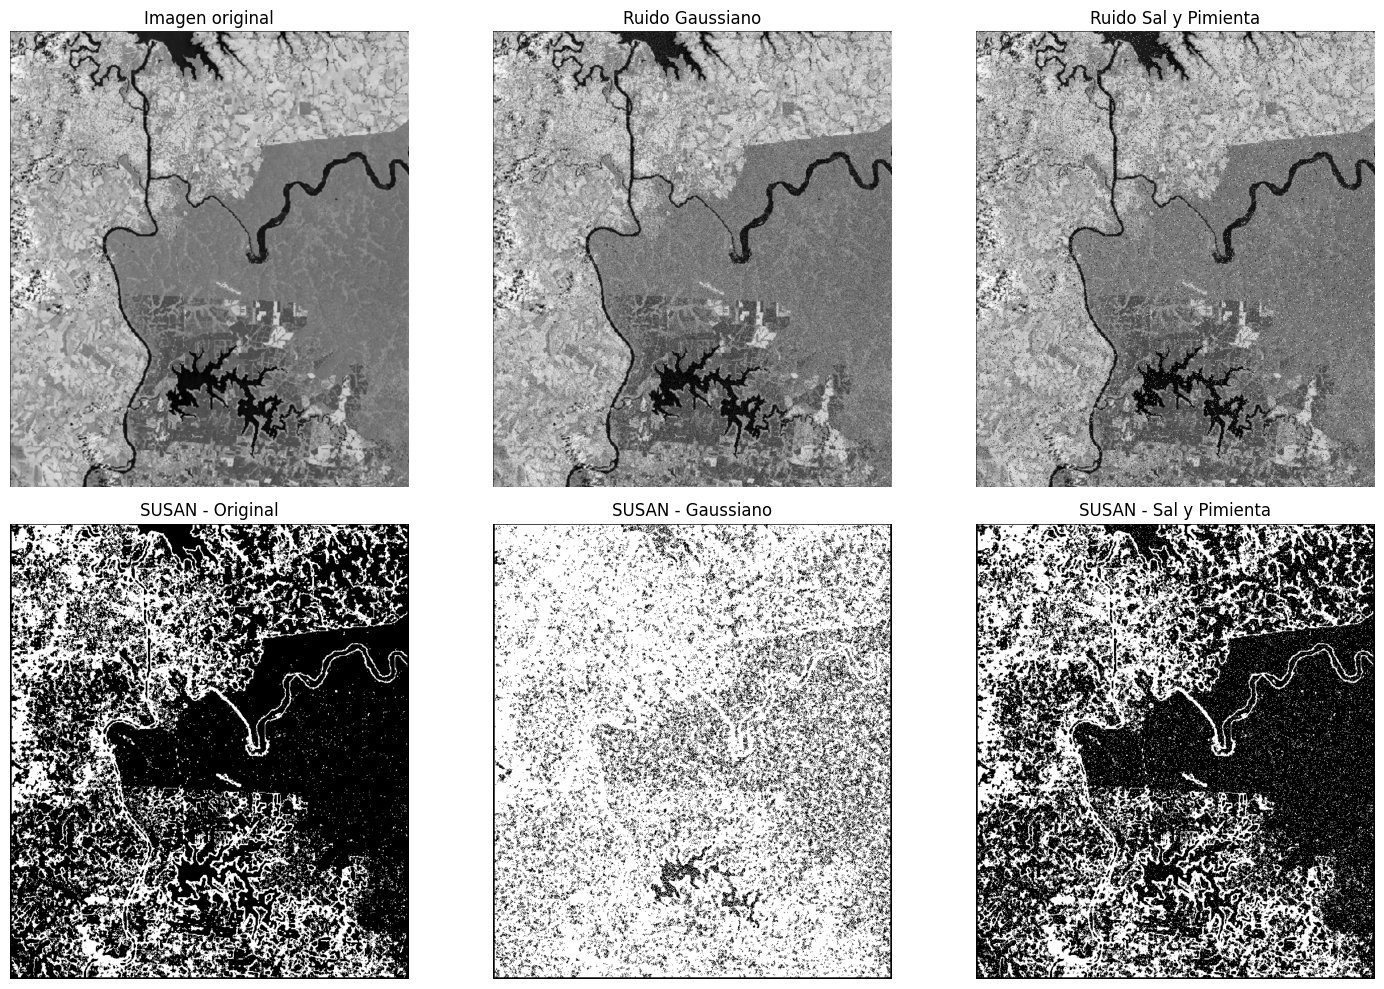

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

# ==========================================================
# 1. Cargar imagen
# ==========================================================

url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales3/refs/heads/main/LC08_224-078-2018-01-05_RGB.jpeg"

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("L")
gray = np.array(img, dtype=np.float32)


# ==========================================================
# 2. Agregar ruido Gaussiano
# ==========================================================

def ruido_gaussiano(imagen, media=0, desviacion=20):
    ruido = np.random.normal(media, desviacion, imagen.shape)
    imagen_ruido = imagen + ruido
    return np.clip(imagen_ruido, 0, 255)


# ==========================================================
# 3. Agregar ruido Sal y Pimienta
# ==========================================================

def ruido_sal_pimienta(imagen, porcentaje=0.05):
    resultado = imagen.copy()

    cantidad = int(porcentaje * imagen.size)

    indices = np.random.choice(imagen.size, cantidad, replace=False)

    mitad = cantidad // 2

    resultado.flat[indices[:mitad]] = 0
    resultado.flat[indices[mitad:]] = 255

    return resultado


# ==========================================================
# 4. SUSAN para detección de bordes
# ==========================================================

def susan_bordes(imagen, radio=3, t=15, umbral=0.5):

    resultado = np.zeros_like(imagen)

    for y in range(radio, imagen.shape[0] - radio):
        for x in range(radio, imagen.shape[1] - radio):

            nucleo = imagen[y, x]

            similares = 0
            total = 0

            for dy in range(-radio, radio + 1):
                for dx in range(-radio, radio + 1):

                    if dx**2 + dy**2 <= radio**2:

                        total += 1

                        vecino = imagen[y + dy, x + dx]

                        if abs(float(vecino) - float(nucleo)) < t:
                            similares += 1

            porcentaje = similares / total

            if porcentaje < umbral:
                resultado[y, x] = 255

    return resultado


# ==========================================================
# 5. Crear imágenes contaminadas
# ==========================================================

imagen_gauss = ruido_gaussiano(gray, desviacion=20)

imagen_sp = ruido_sal_pimienta(gray, porcentaje=0.05)


# ==========================================================
# 6. Aplicar SUSAN
# ==========================================================

susan_original = susan_bordes(gray)

susan_gauss = susan_bordes(imagen_gauss)

susan_sp = susan_bordes(imagen_sp)


# ==========================================================
# 7. Mostrar resultados
# ==========================================================

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(imagen_gauss, cmap="gray")
plt.title("Ruido Gaussiano")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(imagen_sp, cmap="gray")
plt.title("Ruido Sal y Pimienta")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(susan_original, cmap="gray")
plt.title("SUSAN - Original")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(susan_gauss, cmap="gray")
plt.title("SUSAN - Gaussiano")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(susan_sp, cmap="gray")
plt.title("SUSAN - Sal y Pimienta")
plt.axis("off")

plt.tight_layout()
plt.show()

###### Análisis :

> Al aplicar SUSAN a la imagen original, se pueden observar los principales bordes de la imagen de forma clara. Cuando agregamos ruido gaussiano, aparecen algunos bordes que no estaban originalmente, por lo que el resultado se vuelve un poco más confuso.
>
> Con el ruido de sal y pimienta el resultado empeora más, porque los puntos blancos y negros generan cambios fuertes en los píxeles y SUSAN puede detectarlos como bordes.
>
> En general, se puede ver que **el ruido afecta la detección de bordes de SUSAN**, especialmente cuando el ruido es más fuerte. Por eso, sería conveniente aplicar algún filtro para reducir el ruido antes de utilizar SUSAN.


### 4. Contestar las siguientes preguntas téoricas:

##### a) ¿Cuál es el objetivo del método de umbralización de Otsu?

##### R// El objetivo del método de Otsu es encontrar automáticamente un umbral que permita separar una imagen en dos grupos, por ejemplo, objeto y fondo. Busca el valor que mejor separa los niveles de gris de la imagen.

##### b) Describa la etapa de supresión de no máximos del método de Canny. ¿Qué problema soluciona, con respecto al filtro de Sobel?

###### R// La supresión de no máximos en Canny sirve para hacer los bordes más delgados, dejando solamente los píxeles que tienen la mayor intensidad en la dirección del borde.

Con respecto al filtro de Sobel, soluciona el problema de que los bordes pueden quedar gruesos o con varios píxeles de ancho. Canny permite obtener bordes más finos y definidos.

##### c) En el contexto de Análisis y tratamiento de imágenes, ¿qué es una máscara circular?

R// Una máscara circular es una pequeña región con forma de círculo que se coloca sobre una imagen para analizar los píxeles que están alrededor de un punto central. Se utiliza en métodos como SUSAN para comparar los valores de los píxeles vecinos y detectar bordes o características de la imagen.

##### d) ¿Qué es el proceso multilook en imágenes SAR? ¿Para qué sirve?

R// El multilook en imágenes SAR consiste en combinar varias imágenes o “vistas” de la misma zona para obtener una imagen más estable.

Sirve principalmente para reducir el ruido speckle, mejorar la calidad visual de la imagen y hacer más fácil su análisis. El costo es que puede disminuir un poco la resolución espacial.